# 🎨 Data Generator Tutorial

---

## 📚 Overview

This tutorial demonstrates how to use individual components of the synthetic data generator in a **custom manner**.

> **💡 Quick Start Note:**  
> For standard use cases, simply use `generate_dataset.py` - it's highly customizable and ready to go!

---

### 🎯 Purpose

This notebook is to help users who need fine-grained control over:
- **Custom data generation workflows**
- **Individual component configuration**
- **Advanced experimentation with generator internals**

---

In [32]:
from data_generator import SyntheticDataGenerator
from components.noise_generator import NoiseGenerator
from components.nl_sampler import NL_function_generator
from components.lagged_effects import LaggedEffects
from components.instantanous_effects import InstantanousEffects
from components.exog_influences import ExogenousInfluences
import matplotlib.pyplot as plt
import numpy as np

# Assembling General Components

In [4]:
# Set up basic parameters
n_variables = 4
time_series_length = 500
rng = 42

# Set up innovation noise generator
innovation_noise = NoiseGenerator(modus="inno", additive=True, rng=rng)

# Set up observation noise generator
observation_noise = NoiseGenerator(modus="obs", additive=True, snr=5, rng=rng)

# Set up nonlinear function generator if required
nl_generator = NL_function_generator(
    nl_mode="rbf", power_dist=[0.5, 0.6, 1.9, 2], which_power_dist="all", rng=rng
)
# Set up linear structural equation model
structural_model = LaggedEffects(
    n_vars=n_variables,
    link_proba=0.15,
    max_lags=3,
    nonlinear_proba=0.1,
    rng=rng,
    nl_sampler=nl_generator,
)

# Set up instantaneous, potentially, nonlinear effects
instantaneous_effects = InstantanousEffects(
    n_vars=n_variables,
    link_proba=0.2,
    nonlinear_proba=0.5,
    nl_sampler=nl_generator,
    rng=rng,
)

# Set up empty exogenous influences
exogenous_influences = ExogenousInfluences(
    n_vars=n_variables, n_exogs=2, link_proba=0.0, rng=rng
)


In [5]:
# Create the synthetic data generator
data_generator = SyntheticDataGenerator(
    inno_n=innovation_noise,
    obs_n=observation_noise,
    exog=exogenous_influences,
    lagged=structural_model,
    instant=instantaneous_effects,
    rng=rng,
    time_series_n=time_series_length,
    normalize=None,
)

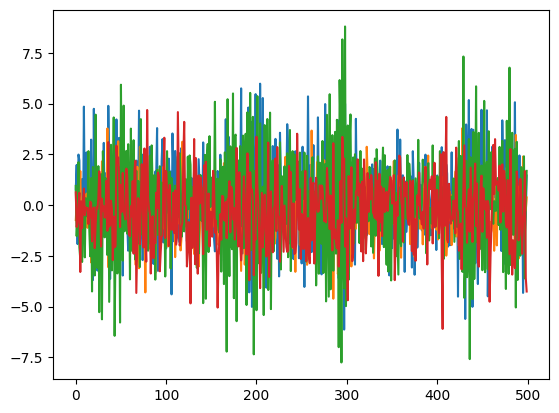

In [20]:
# We can now generate a sample dataset using the configured generator.
# The output will include the generated time series data, lagged and instantanous labels as well as additional information about the nonlinear structures and resampling statistics.
(
    ts,
    lagged_y,
    inst_y,
    exog_y,
    exog_ts,
    nl_struc,
    nl_inst,
    nl_exog,
    resampling_statistics,
) = data_generator.get_sample()
plt.plot(ts.T)
plt.show()

# Individual compoents usage

In [ ]:
# It is also possible to use components individual
instantaneous_effects = InstantanousEffects(
    n_vars=3,
    link_proba=0.1,
    nonlinear_proba=0.5,
    nl_sampler=nl_generator,
    rng=789,
)
instantaneous_effects.init_instantanous_influence()

In [63]:
# Effect x Cause
instantaneous_effects.links

array([[0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.46932608, 0.        , 0.        ]])

In [56]:
# Effect calculated based on the current links and a single time step of the ts.
ts = np.random.uniform(size=(3, 1))
print("Before applying instantaneous effects:", ts.T)
ts  =instantaneous_effects.get_instantanous_effect(ts)
print("After applying instantaneous effects:", ts.T)

Before applying instantaneous effects: [[0.16841672 0.74039882 0.57149147]]
After applying instantaneous effects: [[0.16841672 0.74039882 0.65053383]]


### For more details check tools_and_examples/component_tutorials/ .